In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from fim import arules

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FILES_FOLDER = 'Files/'
OUTPUT_FOLDER = 'Scores/'

In [3]:
df_MBA_VA = pd.read_pickle(FILES_FOLDER+'MBA_VA.pkl')
df_MBA_VA

,Title,Personnel_ID,Personnel_Name,Character
Anime_ID,,,,
1,Cowboy Bebop,"[10004, 10020, 10020, 10021, 10024, 10024, 100...","[Vasconcellos Jorge, Patiño Marco, Patiño Marc...","[Bob, Solensan, Asimov, Vicious, Spiegel, Spik..."
5,Cowboy Bebop: Tengoku no Tobira,"[10004, 10028, 10030, 10155, 10155, 1019, 1059...","[Vasconcellos Jorge, Atala Yamil, Ramirez Alfo...","[Bob, Spiegel, Spike, Black, Jet, Jobim, Anton..."
6,Trigun,"[10021, 1006, 1025, 1025, 10696, 1096, 1097, 1...","[Vilchis José Gilberto, Forstadt Rebecca, Magn...","[the Hornfreak, Midvalley, Elizabeth, Vash the..."
7,Witch Hunter Robin,"[10593, 1088, 1090, 10, 11920, 1268, 1286, 12,...","[Auer Dominik, Magnaghi Debora, Pacotto Emanue...","[Sakaki, Haruto, Sena, Robin, Doujima, Yurika,..."
8,Bouken Ou Beet,"[112, 1138, 145, 1526, 201, 201, 259, 357, 447...","[Midorikawa Hikaru, Cason Chri, Grant Tiffany,...","[Zenon, Grunide, Beet, Slade, Zenon, Shagi, Sh..."
...,...,...,...,...
61211,Mayonaka Heart Tune,"[12041, 24413, 48122]","[Ookubo Rumi, Itou Miku, Suzushiro Sayumi]","[Himekawa, Nene, Uzuki, Shinobu, Kirino, Iko]"
61227,Girls & Panzer: Motto Love Love Sakusen desu!,"[10765, 17007, 17009, 885, 9593]","[Kayano Ai, Ozaki Mami, Nakagami Ikumi, Iguchi...","[Takebe, Saori, Isuzu, Hana, Akiyama, Yukari, ..."
61276,Mikata ga Yowasugite Hojo Mahou ni Tesshiteita...,[55585],[Umeda Shuuichirou],"[Ygret, Alec]"


## Check VA Team Sizes
#### The largest teams are...

In [4]:
df_MBA_VA.set_index('Title').Personnel_ID.apply(len).sort_values(ascending=False).head(20)

Title
One Piece                           3498
Naruto: Shippuuden                  1486
Bleach                              1387
Dragon Ball Z                       1030
Naruto                              1024
Fairy Tail                           895
Hunter x Hunter (2011)               773
Dragon Ball Super                    749
Pokemon                              707
Pokemon Advanced Generation          684
Pokemon Diamond & Pearl              654
Fullmetal Alchemist: Brotherhood     597
Inazuma Eleven                       595
Meitantei Conan                      585
Boruto: Naruto Next Generations      571
Boku no Hero Academia 4th Season     567
Dragon Ball                          551
Pokemon (2019)                       539
Boku no Hero Academia 6th Season     532
Boku no Hero Academia 3rd Season     532
Name: Personnel_ID, dtype: int64

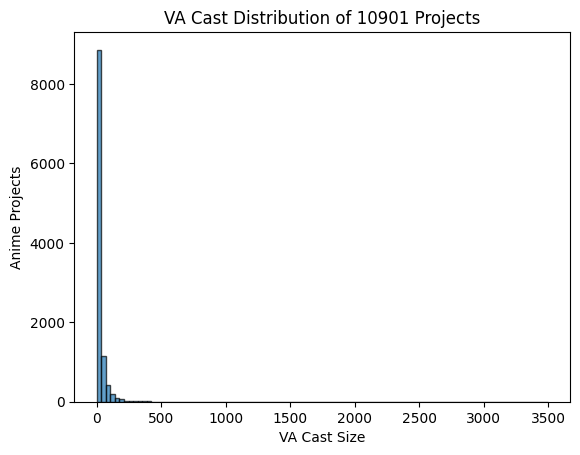

In [5]:
df_MBA_VA.Personnel_ID.apply(len).plot(kind='hist', bins=100, edgecolor='black', alpha=0.7)
plt.title(f'VA Cast Distribution of {df_MBA_VA.shape[0]} Projects')
plt.xlabel('VA Cast Size')
plt.ylabel('Anime Projects')
plt.show()

# Modeling

In [6]:
X_train, X_test = train_test_split(df_MBA_VA, test_size=0.2, random_state=42)
print('Train size:\t', X_train.shape)
print('Test size:\t', X_test.shape)

Train size:	 (8720, 4)
Test size:	 (2181, 4)


# What the Parameters mean

### Support
In how many anime projects, has the personnel **worked/appeared in**?

### Confidence
**Personnel B** Acceptance Rate

Given **Team A** is casted, what's the likelihood of **Personnel B** to accept?<br>
Compares the history of Team working with Personnel B.


### Lift
Colab chance vs Solo

How much more likely the colab is to push through than separate projects.

### Zmin
The final team size (Target hire + Required team).

In [7]:
def GenerateRules(X : pd.DataFrame, MIN_PROJECTS = -20, ACCEPTANCE_RATE = 20, TEAM_SIZE = 5):
    report = 'bhaCL'
    header = ['Target_Hire', 'Required_Team', 'Projects_Taken(X)', 'Projects_Taken(Y)', 'Colab_Projects(X,Y)',  'Acceptance(Confidence%)', 'Colab(Lift%)']
    
    result = arules(X['Personnel_ID'].to_list(), 
                    supp=MIN_PROJECTS, 
                    conf=ACCEPTANCE_RATE,
                    zmin = TEAM_SIZE,
                    report=report)
    
    df = pd.DataFrame(result, columns=header).sort_values('Colab(Lift%)', ascending=False)
    return df

In [8]:
def FilterRules(df_Rules : pd.DataFrame, EXISTING_CAST_IDS : tuple = None, TARGET_HIRE_ID : int = None):
    df_Filtered = df_Rules.copy()

    if TARGET_HIRE_ID is not None:
        df_Filtered = df_Filtered[df_Filtered['Target_Hire'] == TARGET_HIRE_ID]
        
    if EXISTING_CAST_IDS is not None:
        df_Filtered = df_Filtered[df_Filtered['Required_Team'].apply(lambda x: all(i in x for i in EXISTING_CAST_IDS))]
    
    return df_Filtered

In [9]:
DB_PERSONNEL_RECORDS = pd.read_pickle(FILES_FOLDER+'Personnels_VA.pkl')

def ContextualizeID(df_FilteredRules : pd.DataFrame):
    df_Result = pd.DataFrame()
    
    for p in (df_FilteredRules.Target_Hire,) + df_FilteredRules.Required_Team:
        df_Result = pd.concat([df_Result, DB_PERSONNEL_RECORDS.loc[p][['Character', 'Title']].rename(index={'Character':DB_PERSONNEL_RECORDS.loc[p].Personnel_Name}).apply(pd.Series).T], axis=1)
    
    return df_Result.T

## How It Works

Generate the Rules from all the Anime casting lists:

<ol>
    <li> `MIN_PROJECTS` - Minimum number of Anime Projects the Team must have accomplished.</li>
    <li> `ACCEPTANCE_RATE` - Minimum likelihhod the Hire will accept, given the team.</li>
    <li> `TEAM_SIZE` - Minimum size of the suggested Team + Hire.</li>
</ol>


In [10]:
df_Rules = GenerateRules(X=X_train, MIN_PROJECTS = -30, ACCEPTANCE_RATE = 20, TEAM_SIZE = 4)
df_Rules

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
906815,57720,"(659, 472, 9087, 159)",30,6,6,20.000000,29066.666667
935053,35499,"(1529, 1024, 9932, 128)",30,10,10,33.333333,29066.666667
935054,35499,"(1529, 1024, 9932)",30,10,10,33.333333,29066.666667
935056,35499,"(1529, 678, 128)",30,10,10,33.333333,29066.666667
935045,35499,"(1529, 9932, 128)",30,10,10,33.333333,29066.666667
...,...,...,...,...,...,...,...
950,79,"(472, 313, 159)",65,436,13,20.000000,400.000000
56675,79,"(859, 472, 860)",30,436,6,20.000000,400.000000
53682,159,"(356, 5626, 672)",30,461,6,20.000000,378.308026
95855,159,"(55714, 42869, 42636)",30,461,6,20.000000,378.308026


## [Optional] Filter for your needs 
#### Example on #160. Dio Wrio (Jojo) VA

<ol>
    <li>`df_Rules` - The generated rules dataframe</li>
    <li>`EXISTING_CAST_IDS` - [Optional] The current cast already possessed.</li>
    <li>`TARGET_HIRE_ID` - [Optional] A hire you're seeking.</li>
</ol>

### Why filter?
It's a utility to narrow down the rules. We're only concenrened with evaluating those are related to the Hire/Team.

Otherwise we would need to evaluate {df_Rules}

In [11]:
df_Filtered = FilterRules(df_Rules, EXISTING_CAST_IDS=None, TARGET_HIRE_ID=160)
print(f'Selected : {df_Filtered.shape[0]}/{df_Rules.shape[0]}')
df_Filtered

Selected : 837/947787


,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
107419,160,"(7350, 7974, 1108)",30,399,15,50.000000,1092.731830
36048,160,"(5138, 1442, 1108)",31,399,15,48.387097,1057.482416
92711,160,"(42840, 20242, 37631)",30,399,14,46.666667,1019.883041
23360,160,"(26505, 9237, 26639)",31,399,14,45.161290,986.983588
109875,160,"(26525, 26639, 24293)",32,399,14,43.750000,956.140351
...,...,...,...,...,...,...,...
30627,160,"(666, 472, 159)",40,399,8,20.000000,437.092732
4265,160,"(1047, 1602, 313, 253)",30,399,6,20.000000,437.092732
125156,160,"(203, 312, 472)",30,399,6,20.000000,437.092732
373237,160,"(1024, 553, 14, 22)",30,399,6,20.000000,437.092732


## Contextualize the IDs

First 2 rows is the Target Hire.
Succeeding are the other VAs.

In [12]:
ContextualizeID(df_Filtered.iloc[0])

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Koyasu Takehito,Takasugi Shinsuke,Fushiguro Touji,Shindou Ainosuke,Vasaago,Zeke,Takahashi Ryousuke,Barzini Finocchio,Hatakeyama,Mathers Roswaal L.,Hugh,...,Aiba Shinya,Seven-Changer,Snufkin,Snufkin,Joxaren,Happosai,Kengyu,Kuroki Gai,Corn-kun,Kurageman
Title,3-nen Z-gumi Ginpachi-sensei,Jujutsu Kaisen: Kaigyoku/Gyokusetsu,SK∞ OVA: Extra Part,"S-Rank Monster no ""Behemoth"" dakedo, Neko to M...",Shingeki no Kyojin Movie: Kanketsu-hen - The L...,MF Ghost 2nd Season,"Saikyou no Shienshoku ""Wajutsushi"" de Aru Ore ...",Touhai: Ura Rate Mahjong Touhairoku,Re:Zero kara Hajimeru Isekai Seikatsu 3rd Season,Acro Trip,...,Uchuu no Kishi Tekkaman Blade,Densetsu no Yuusha da Garn,Tanoshii Muumin Ikka Bouken Nikki,Tanoshii Muumin Ikka,Tanoshii Muumin Ikka,Ranma ½,Ranma ½,Tenkuu Senki Shurato,Sore Ike! Anpanman,Sore Ike! Anpanman
Rollo Alfredo,Vegeta,Kunou Tatewaki,Slantania Seigfried,Takeshi,Petrov Yuri,Vegeta,Petrov Yuri,Takeshi,Slantania Seigfried,Sugimoto Ryou,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Dragon Ball Daima,Ranma ½ (2024),Seijo no Maryoku wa Bannou desu Season 2,Pokemon: Mezase Pokemon Master,Tiger & Bunny 2 Part 2,Dragon Ball Super: Super Hero,Tiger & Bunny 2,Pokemon (2019): Kami to Yobareshi Arceus,Seijo no Maryoku wa Bannou desu,Shaman King (2021),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lima Wellington,Majin Buu,Zaraki Kenpachi,Ozma Barack,Zaraki Kenpachi,Taneda Santouka,Zaraki Kenpachi,Lopez Antonio,Gerard,Director Yamamoto,Hishigata Seidou,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Dragon Ball Daima,Bleach: Sennen Kessen-hen - Soukoku-tan,Hanma Baki: Son of Ogre 2nd Season,Bleach: Sennen Kessen-hen - Ketsubetsu-tan,Bungou Stray Dogs 4th Season,Bleach: Sennen Kessen-hen,Tiger & Bunny 2 Part 2,Kuro no Shoukanshi,Spriggan (ONA),Summertime Render,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lucindo Fábio,Legoshi,Kuririn,Ichirou,Kurosaki Ichigo,Bakugou Katsuki,Bakugou Katsuki,Iver Ramon,Bakugou Katsuki,Tao Ren,Pluto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,Beastars Final Season,Dragon Ball Daima,Ranma ½ (2024),Bleach: Sennen Kessen-hen - Soukoku-tan,Boku no Hero Academia the Movie 4: You're Next,Boku no Hero Academia 7th Season,Maou Gakuin no Futekigousha II: Shijou Saikyou...,Boku no Hero Academia: Memories,Shaman King: Flowers,Pluto,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Statistical
Unfortunately it's too unfamiliar to make sense of the context from Character Names.

We'll use a statistical evaluation instead.

## Precision
Precision evaluates all the suggestions made, whether these were True or False Positives.

Basically, compare the Projects with just the Team(X), against those with the Team + Hire(X,Y)

A `True Positive` is a project containing both Team and Hire.

A `False Positive` is a project only containing the Team.

In [13]:
REQ_TEAM = df_Filtered.iloc[0].Required_Team
REQ_HIRE = df_Filtered.iloc[0].Target_Hire

result = dict()

df_TeamProjects = X_train[X_train.Personnel_ID.apply(lambda x: set(REQ_TEAM).issubset(x))]
result['Team_Projects'] = df_TeamProjects.shape[0] 

#### The recommended projects.

In [14]:
df_TeamProjects

,Title,Personnel_ID,Personnel_Name,Character
Anime_ID,,,,
906,Dragon Ball Z Movie 13: Ryuuken Bakuhatsu!! Go...,"[1000, 10012, 10575, 1087, 1090, 1108, 11332, ...","[Schemmel Sean, Urbschatmingues Claudia, Chant...","[Son, Gokuu, Bulma, Kuririn, Vegeta, Bulma, Ku..."
30,Shinseiki Evangelion,"[1001, 10491, 10734, 1085, 1094, 1095, 10, 110...","[Pfeiffer Marku, Rodríguez Toni, Joudrier Tony...","[Nagisa, Kaworu, Katsuragi, Misato, Aoba, Shig..."
22,Tennis no Oujisama,"[10158, 10232, 10503, 1071, 10784, 10784, 1083...","[Granadillo José, Chacón Lileana, Tobayama Bun...","[Tezuka, Kunimitsu, Katou, Kachirou, Ojii, Ama..."
14837,Dragon Ball Z Movie 14: Kami to Kami,"[1000, 1000, 10019, 10021, 10021, 10028, 10063...","[Schemmel Sean, Schemmel Sean, Mendoza Ricardo...","[Son, Gokuu, North Kaio, Yamcha, Higashi no Ka..."
154,Shaman King,"[1000, 1000, 1000, 10019, 10023, 1024, 1045, 1...","[Schemmel Sean, Schemmel Sean, Schemmel Sean, ...","[Amidamaru, Umemiya, Ryuunosuke, Nichrom, Kali..."
223,Dragon Ball,"[1000, 10019, 1001, 10023, 10023, 10023, 10024...","[Schemmel Sean, Mendoza Ricardo, Pfeiffer Mark...","[Son, Gokuu, Yamcha, General Blue, Staff Offic..."
3785,Evangelion Movie 3: Q,"[10706, 10734, 1095, 1108, 11521, 11695, 1178,...","[Petrick Dirk, Joudrier Tony, Corvo Massimo, L...","[Nagisa, Kaworu, Aoba, Shigeru, Ikari, Gendou,..."
985,Dragon Ball Z Special 2: Zetsubou e no Hankou!...,"[10575, 10575, 10631, 1087, 1088, 1090, 1092, ...","[Chantal Claude, Chantal Claude, Antonelli Mon...","[Kuririn, Pu'ar, Pu'ar, Vegeta, Jinzouningen 1..."
52291,Tiger & Bunny 2 Part 2,"[10081, 10729, 10989, 1108, 11369, 11403, 1163...","[Dittman Henry, Strempler Christian, Shimazaki...","[Goldsmith, Ryan, Kaburagi, Kotetsu T., Taurus..."


#### The accepted colabs.

In [15]:
result['Colab_Projects'] = df_TeamProjects[df_TeamProjects.Personnel_ID.apply(lambda x: REQ_HIRE in x)].shape[0]
df_TeamProjects[df_TeamProjects.Personnel_ID.apply(lambda x: REQ_HIRE in x)]

,Title,Personnel_ID,Personnel_Name,Character
Anime_ID,,,,
30,Shinseiki Evangelion,"[1001, 10491, 10734, 1085, 1094, 1095, 10, 110...","[Pfeiffer Marku, Rodríguez Toni, Joudrier Tony...","[Nagisa, Kaworu, Katsuragi, Misato, Aoba, Shig..."
154,Shaman King,"[1000, 1000, 1000, 10019, 10023, 1024, 1045, 1...","[Schemmel Sean, Schemmel Sean, Schemmel Sean, ...","[Amidamaru, Umemiya, Ryuunosuke, Nichrom, Kali..."
3785,Evangelion Movie 3: Q,"[10706, 10734, 1095, 1108, 11521, 11695, 1178,...","[Petrick Dirk, Joudrier Tony, Corvo Massimo, L...","[Nagisa, Kaworu, Aoba, Shigeru, Ikari, Gendou,..."
45,Rurouni Kenshin: Meiji Kenkaku Romantan,"[1059, 10733, 10734, 1082, 108, 1108, 1108, 11...","[Sherman Dina, Popovic Frédéri, Joudrier Tony,...","[Oguni, Ayame, Sagara, Sanosuke, Shinomori, Ao..."
42205,Shaman King (2021),"[10019, 10024, 1024, 10273, 10572, 10733, 1073...","[Mendoza Ricardo, Reyero Gerardo, Inuyama Inuk...","[Kalim, Bason, Oyamada, Manta, Lasso, Luchist,..."
1614,Captain Tsubasa: Road to 2002,"[10019, 106, 1098, 1108, 1110, 1124, 11332, 11...","[Mendoza Ricardo, Masuda Yuki, Manfredi Massim...","[Hyuuga, Kojirou, Urabe, Hanji, Ishizaki, Ryou..."
210,Ranma ½,"[10024, 10076, 1026, 10401, 10593, 10754, 1077...","[Reyero Gerardo, Kitamura Kouichi, Nanba Keiic...","[Sanzenin, Mikado, Kaminarimon, Kumajiro, Char..."
269,Bleach,"[10019, 1001, 10021, 10021, 10024, 1002, 1003,...","[Mendoza Ricardo, Pfeiffer Marku, Vilchis José...","[Aizen, Sousuke, Ishida, Uryuu, Shiba, Kaien, ..."
527,Pokemon,"[10037, 1024, 1045, 1045, 1045, 1045, 1045, 10...","[Combrinck Caroline, Inuyama Inuko, Hollingshe...","[Satoshi, Nyarth, Joy, Yamato, Akane, Ibuki, B..."


### Verify that our Rules is Fitted to the Training Data

In [16]:
assert df_Filtered.iloc[0]['Projects_Taken(X)'] == result['Team_Projects']
assert df_Filtered.iloc[0]['Colab_Projects(X,Y)'] == result['Colab_Projects']

In [17]:
print(df_Filtered.iloc[0])
print('\n\n\t', result)

print(f'\n\nIf we recommended all the {result["Team_Projects"]} team projects, but only {result["Colab_Projects"]} had the Hire present,')
print(f'Our score would be {result["Colab_Projects"]/result["Team_Projects"]}')
print(f'False positives: {result["Team_Projects"] - result["Colab_Projects"]}')

Target_Hire                               160
Required_Team              (7350, 7974, 1108)
Projects_Taken(X)                          30
Projects_Taken(Y)                         399
Colab_Projects(X,Y)                        15
Acceptance(Confidence%)                  50.0
Colab(Lift%)                       1092.73183
Name: 107419, dtype: object


	 {'Team_Projects': 30, 'Colab_Projects': 15}


If we recommended all the 30 team projects, but only 15 had the Hire present,
Our score would be 0.5
False positives: 15


In [20]:
def EvaluateRules(df_Rules : pd.DataFrame, X : pd.DataFrame):
    all_Results = []
    for _, row in df_Rules.iterrows():
        REQ_TEAM = row.Required_Team
        REQ_HIRE = row.Target_Hire
    
        result = dict()
        
        df_TeamProjects = X[X.Personnel_ID.apply(lambda x: set(REQ_TEAM).issubset(x))]
        result['Team_Projects'] = df_TeamProjects.shape[0] 
        result['Colab_Projects'] = df_TeamProjects[df_TeamProjects.Personnel_ID.apply(lambda x: REQ_HIRE in x)].shape[0]

        result['False_Positives'] = result['Team_Projects'] - result['Colab_Projects']
        
        # IF no matches, then prediction is 0.
        try:
            result['Score'] = result['Colab_Projects'] / result['Team_Projects']
        except:
            result['Score'] = np.nan
        
        all_Results.append(result)


    df_Score = pd.DataFrame(all_Results)
    df_Score[df_Rules.columns[:2]] = df_Rules.reset_index().iloc[:,1:3]
    df_Score.sort_values('Score', ascending=False, inplace=True)
    
    print('Average:\n')
    print((df_Score.iloc[:,:4].mean()))

    return df_Score

## Train Score

In [21]:
EvaluateRules(df_Filtered, X_train.head(10))

Average:

Team_Projects      0.002389
Colab_Projects     0.000000
False_Positives    0.002389
Score              0.000000
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
226,1,0,1,0.0,160,"(25405, 37631, 1268)"
481,1,0,1,0.0,160,"(396, 10, 340)"
0,0,0,0,NaN,160,"(7350, 7974, 1108)"
1,0,0,0,NaN,160,"(5138, 1442, 1108)"
2,0,0,0,NaN,160,"(42840, 20242, 37631)"
...,...,...,...,...,...,...
832,0,0,0,NaN,160,"(666, 472, 159)"
833,0,0,0,NaN,160,"(1047, 1602, 313, 253)"
834,0,0,0,NaN,160,"(203, 312, 472)"
835,0,0,0,NaN,160,"(1024, 553, 14, 22)"


## Test Score

In [22]:
EvaluateRules(df_Filtered, X_test).head(10)

Average:

Team_Projects      7.603345
Colab_Projects     0.982079
False_Positives    6.621266
Score              0.115123
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
793,3,2,1,0.666667,160,"(666, 192, 253)"
814,2,1,1,0.500000,160,"(475, 312, 472, 253)"
715,4,2,2,0.500000,160,"(475, 472, 189, 253)"
62,4,2,2,0.500000,160,"(23445, 891, 253)"
123,4,2,2,0.500000,160,"(201, 192, 189)"
129,4,2,2,0.500000,160,"(1289, 1090, 1268)"
8,4,2,2,0.500000,160,"(30379, 1047, 1602)"
189,7,3,4,0.428571,160,"(302, 202, 1602)"
226,7,3,4,0.428571,160,"(25405, 37631, 1268)"
2,7,3,4,0.428571,160,"(42840, 20242, 37631)"


# Refine
Even with just training and test data, the scores don't look good.

A vast disparity between Train and Test scores could indicate Overfitting (Train > Test) or Underfitting.

Let's try increasing the parameters.

## 1. Increase Support Threshold

In [23]:
df_Rules = GenerateRules(X=X_train, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 20, TEAM_SIZE = 4)
df_Rules.head()

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
8443,9187,"(360, 202, 253)",50,10,10,20.000000,17440.000000
8265,10559,"(678, 14, 22)",52,16,16,30.769231,16769.230769
8266,10559,"(678, 14, 128, 22)",52,16,16,30.769231,16769.230769
8255,10559,"(14, 128, 357)",53,16,16,30.188679,16452.830189
8264,10559,"(678, 128, 22)",53,16,16,30.188679,16452.830189


In [24]:
EvaluateRules(df_Rules, X_train).head()

Average:

Team_Projects      54.476196
Colab_Projects     17.530910
False_Positives    36.945287
Score               0.322216
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
1997,51,51,0,1.0,128,"(678, 1024, 22)"
1993,52,52,0,1.0,128,"(678, 1024, 14)"
1996,51,51,0,1.0,128,"(678, 1024, 14, 22)"
3263,51,51,0,1.0,14,"(678, 1024, 22)"
3262,51,51,0,1.0,14,"(678, 1024, 128, 22)"


In [25]:
EvaluateRules(df_Rules, X_test).head()

Average:

Team_Projects      12.999053
Colab_Projects      3.681075
False_Positives     9.317977
Score               0.284544
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
345,7,7,0,1.0,1024,"(14, 58, 128)"
4662,8,8,0,1.0,22,"(678, 1024, 128)"
3263,8,8,0,1.0,14,"(678, 1024, 22)"
3262,8,8,0,1.0,14,"(678, 1024, 128, 22)"
5064,7,7,0,1.0,22,"(1024, 14, 58, 128)"


#### Increased Support
Still low precision...

## 2. Increase Confidence

In [26]:
df_Rules = GenerateRules(X=X_train, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 50, TEAM_SIZE = 4)
df_Rules.head()

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
934,42602,"(678, 1024, 14, 128, 22)",51,31,28,54.901961,15443.390259
930,42602,"(678, 1024, 22)",51,31,28,54.901961,15443.390259
931,42602,"(678, 1024, 128, 22)",51,31,28,54.901961,15443.390259
933,42602,"(678, 1024, 14, 22)",51,31,28,54.901961,15443.390259
959,25287,"(678, 1024, 128, 22)",51,36,32,62.745098,15198.257081


In [27]:
EvaluateRules(df_Rules, X_train).head()

Average:

Team_Projects      54.181725
Colab_Projects     33.330595
False_Positives    20.851129
Score               0.616007
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
358,52,52,0,1.0,128,"(678, 1024, 14)"
357,51,51,0,1.0,128,"(678, 1024, 14, 22)"
356,53,53,0,1.0,128,"(1024, 14, 22)"
355,51,51,0,1.0,128,"(678, 1024, 22)"
558,51,51,0,1.0,14,"(678, 1024, 128, 22)"


In [28]:
EvaluateRules(df_Rules, X_test)

Average:

Team_Projects      11.928131
Colab_Projects      6.691992
False_Positives     5.236140
Score               0.560698
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
573,9,9,0,1.000000,14,"(678, 128, 22)"
572,10,10,0,1.000000,14,"(1024, 128, 22)"
604,7,7,0,1.000000,14,"(58, 128, 22)"
109,7,7,0,1.000000,1024,"(14, 58, 128)"
755,9,9,0,1.000000,22,"(678, 14, 128)"
...,...,...,...,...,...,...
247,16,3,13,0.187500,203,"(312, 253, 159)"
483,16,3,13,0.187500,202,"(1804, 1602, 159)"
438,18,3,15,0.166667,650,"(659, 472, 253)"
523,12,2,10,0.166667,202,"(891, 312, 159)"


#### Increased Support and Confidence
Significantly better Percision.

Attributed to increased successful Colabs and consequently, lower False Positives.

## 3. Increase Zmin

In [29]:
df_Rules = GenerateRules(X=X_train, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 50, TEAM_SIZE = 6)
df_Rules.head()

,Target_Hire,Required_Team,Projects_Taken(X),Projects_Taken(Y),"Colab_Projects(X,Y)",Acceptance(Confidence%),Colab(Lift%)
16,42602,"(678, 1024, 14, 128, 22)",51,31,28,54.901961,15443.390259
17,25287,"(678, 1024, 14, 128, 22)",51,36,32,62.745098,15198.257081
18,44999,"(678, 1024, 14, 128, 22)",51,32,26,50.980392,13892.156863
15,26299,"(678, 1024, 14, 128, 22)",51,41,32,62.745098,13344.811095
10,23633,"(678, 1024, 14, 128, 22)",51,48,32,62.745098,11398.692810


In [30]:
EvaluateRules(df_Rules, X_train).head()

Average:

Team_Projects      51.000000
Colab_Projects     32.105263
False_Positives    18.894737
Score               0.629515
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
14,51,45,6,0.882353,357,"(678, 1024, 14, 128, 22)"
17,51,44,7,0.862745,58,"(678, 1024, 14, 128, 22)"
8,51,35,16,0.686275,9932,"(678, 1024, 14, 128, 22)"
15,51,35,16,0.686275,1160,"(678, 1024, 14, 128, 22)"
18,51,32,19,0.627451,1090,"(678, 1024, 14, 128, 22)"


In [31]:
EvaluateRules(df_Rules, X_test).head()

Average:

Team_Projects      8.000000
Colab_Projects     4.315789
False_Positives    3.684211
Score              0.539474
dtype: float64


,Team_Projects,Colab_Projects,False_Positives,Score,Target_Hire,Required_Team
0,8,5,3,0.625,42602,"(678, 1024, 14, 128, 22)"
1,8,5,3,0.625,25287,"(678, 1024, 14, 128, 22)"
3,8,5,3,0.625,26299,"(678, 1024, 14, 128, 22)"
9,8,5,3,0.625,57717,"(678, 1024, 14, 128, 22)"
4,8,5,3,0.625,23633,"(678, 1024, 14, 128, 22)"


#### Increased Support, Confidence, and Zmin
Significant improvement to Overfitting issue. 

Ranges between Train and Test precision is now much closer.

# Find the Best Parameters

In [32]:
def ScoreParameters(df_X_train, df_X_test, SUPPORT_RANGE, CONFIDENCE_RANGE, Z_RANGE = np.arange(4, 6)):
    df_MutltipleTests = pd.DataFrame()
    
    for ZMIN in Z_RANGE:        
        df_Rules = GenerateRules(X = df_X_train, MIN_PROJECTS = SUPPORT_RANGE[-1], ACCEPTANCE_RATE = CONFIDENCE_RANGE[0], TEAM_SIZE = ZMIN)
        
        for SUPPORT in SUPPORT_RANGE:
            confidenceSplice = df_Rules[df_Rules['Projects_Taken(X)'] >= abs(SUPPORT)].copy()
    
            for CONFIDENCE in CONFIDENCE_RANGE:
                print(f'Eval Z:{ZMIN}, Support: {SUPPORT}, Confidence:{CONFIDENCE}')
                
                confidenceSplice = confidenceSplice[confidenceSplice['Acceptance(Confidence%)'] >= CONFIDENCE]
    
                try:    
                    df_Score = EvaluateRules(confidenceSplice, df_X_train)
                    results = {
                        'Total_'+df_Score.columns[0] : df_Score.iloc[:,0].sum(),
                        'Total_'+df_Score.columns[1] : df_Score.iloc[:,1].sum(),
                        'Total_'+df_Score.columns[2] : df_Score.iloc[:,2].sum(),
                        'Avg_'+df_Score.columns[0] : df_Score.iloc[:,0].mean(),
                        'Avg_'+df_Score.columns[1] : df_Score.iloc[:,1].mean(),
                        'Avg_'+df_Score.columns[2] : df_Score.iloc[:,2].mean(),
                        'Avg_'+df_Score.columns[3] : df_Score.iloc[:,3].mean(),
                        'Min_Projects' : SUPPORT,
                        'Min_Acceptance' : CONFIDENCE,
                        'Min_Team' : ZMIN,
                        'Is_Train' : True
                    }
                    df_MutltipleTests = pd.concat([df_MutltipleTests, pd.DataFrame([results])], axis=0, ignore_index=True)
                except Exception as e:
                    print(f'No results {e}')
                    continue
    
                try:
                    df_Score = EvaluateRules(confidenceSplice, df_X_test)
                    results = {
                        'Total_'+df_Score.columns[0] : df_Score.iloc[:,0].sum(),
                        'Total_'+df_Score.columns[1] : df_Score.iloc[:,1].sum(),
                        'Total_'+df_Score.columns[2] : df_Score.iloc[:,2].sum(),
                        'Avg_'+df_Score.columns[0] : df_Score.iloc[:,0].mean(),
                        'Avg_'+df_Score.columns[1] : df_Score.iloc[:,1].mean(),
                        'Avg_'+df_Score.columns[2] : df_Score.iloc[:,2].mean(),
                        'Avg_'+df_Score.columns[3] : df_Score.iloc[:,3].mean(),
                        'Min_Projects' : SUPPORT,
                        'Min_Acceptance' : CONFIDENCE,
                        'Min_Team' : ZMIN,
                        'Is_Train' : False
                    }
                    df_MutltipleTests = pd.concat([df_MutltipleTests, pd.DataFrame([results])], axis=0, ignore_index=True)
                except Exception as e:
                    print(f'No results {e}')
                    
    return df_MutltipleTests

In [ ]:
df_ParamScores = ScoreParameters(df_X_train = X_train, df_X_test = X_test, SUPPORT_RANGE= np.arange(-35, -19, 5), CONFIDENCE_RANGE= np.arange(25, 76, 25))
df_ParamScores.to_csv(OUTPUT_FOLDER+ 'ARules_Scores_VA.csv')

# df_ParamScores = pd.read_csv(OUTPUT_FOLDER+ 'ARules_Scores_VA.csv')
df_ParamScores

### Plot our Results from Different Parameters

In [ ]:
df_ParamScores['Min_Projects'] = df_ParamScores['Min_Projects'].abs()
sns.pairplot(df_ParamScores.loc[:,'Avg_Team_Projects':], hue='Is_Train', diag_kind='hist')

### Analysis

Unsurprisingly, train scores are better than test scores.

## Best Parameters?

In [ ]:
df_ParamScores.set_index(['Min_Projects', 'Min_Acceptance', 'Min_Team', 'Is_Train']).sort_values('Avg_Score', ascending=False)

# Discussion
Generally, we see the best scores to be the ones that maximize support, confidence, and team size.

Due to this, the number of rules provided reduces and thereby, also reducing the Total number of items to evaluate.

In short, because the rule is specific on the most frequent patterns, less item sets are given. We even see a cutoff from certain ranges wherein scores no longer change meaning the same item sets are being recommended.

# Try it on Staff solo, as well as VA + Staff Combined

## Staff

In [ ]:
df_MBA_Staff = pd.read_pickle(FILES_FOLDER+'MBA_Staff.pkl')
X_train_staff, X_test_staff = train_test_split(df_MBA_Staff, random_state=42, test_size=0.2)

print('Staff Train', X_train_staff.shape)
print('Staff Test', X_test_staff.shape)

df_MBA_Staff

In [ ]:
df_MBA_Staff.Personnel_ID.apply(len).plot(kind='hist', bins=100, edgecolor='black', alpha=0.7)
plt.title(f'Staff Distribution of {df_MBA_Staff.shape[0]} Projects')
plt.xlabel('Staff Size')
plt.ylabel('Anime Projects')
plt.show()

In [ ]:
MLB = MultiLabelBinarizer()
jobs = pd.DataFrame(MLB.fit_transform(df_MBA_Staff.Role), columns=MLB.classes_).sum().sort_values(ascending=False)
jobs

In [ ]:
jobs.plot(kind='pie')
plt.title(f'Staff Composition of {df_MBA_Staff.shape[0]} Projects')
plt.show()

## Combined

In [ ]:
df_MBA_Combined = pd.merge(df_MBA_VA, df_MBA_Staff, on='Anime_ID', how='outer')

df_MBA_Combined['Personnel_ID_x'] = df_MBA_Combined['Personnel_ID_x'].apply(lambda x: [] if isinstance(x, float) and np.isnan(x) else x)
df_MBA_Combined['Personnel_ID_y'] = df_MBA_Combined['Personnel_ID_y'].apply(lambda x: [] if isinstance(x, float) and np.isnan(x) else x)

df_MBA_Combined['Personnel_ID'] = [x + y for x, y in zip(df_MBA_Combined['Personnel_ID_x'], df_MBA_Combined['Personnel_ID_y'])]
df_MBA_Combined = df_MBA_Combined[['Personnel_ID']]

X_train_combined, X_test_combined= train_test_split(df_MBA_Combined, random_state=42, test_size=0.2)


print('Combined Test', X_train_combined.shape)
print('Combined Test', X_test_combined.shape)

df_MBA_Combined

### Compare VA vs Staff rules.

`MIN_PROJECTS = -50`

Compared to Voice Actors, Staff had more rules discovered.

This may be attributed to the fact that they are internal studio employees instead of external hires/freelancers like voice actors are.

They are exposed to more projects under the same studio.

In [ ]:
df_Rules = GenerateRules(X = X_train, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 1, TEAM_SIZE = 4)
print('VA Rules: ', df_Rules.shape[0])
df_Rules = GenerateRules(X = X_train_staff, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 1, TEAM_SIZE = 4)
print('Staff Rules: ', df_Rules.shape[0])
df_Rules = GenerateRules(X = X_train_combined, MIN_PROJECTS = -50, ACCEPTANCE_RATE = 1, TEAM_SIZE = 4)
print('VA & Staff Combined Rules: ', df_Rules.shape[0])

# Staff Parameters

### Find the Best Parameters for Staff

In [ ]:
df_ParamScores = ScoreParameters(df_X_train = X_train_staff, df_X_test = X_test_staff, SUPPORT_RANGE= np.arange(-15, -10, 5), CONFIDENCE_RANGE= np.arange(5, 16, 5))
df_ParamScores['Min_Projects'] = df_ParamScores['Min_Projects'].abs()
sns.pairplot(df_ParamScores.loc[:,'Avg_Team_Projects':], hue='Is_Train', diag_kind='hist')

In [ ]:
df_ParamScores.to_csv(OUTPUT_FOLDER+ 'ARules_Staff_Score.csv')
df_ParamScores.set_index(['Min_Projects', 'Min_Acceptance', 'Min_Team', 'Is_Train']).sort_values('Avg_Score', ascending=False)

# Combined Parameters

### Find the Best Parameters for Combined VA & Staff

In [ ]:
df_ParamScores = ScoreParameters(df_X_train = X_train_combined, df_X_test = X_test_combined, SUPPORT_RANGE= np.arange(-30, -14, 5), CONFIDENCE_RANGE= np.arange(25, 76, 25))
df_ParamScores['Min_Projects'] = df_ParamScores['Min_Projects'].abs()
sns.pairplot(df_ParamScores.loc[:,'Avg_Team_Projects':], hue='Is_Train', diag_kind='hist')

In [ ]:
df_ParamScores.to_csv(OUTPUT_FOLDER+ 'ARules_Combined_Score.csv')
df_ParamScores.set_index(['Min_Projects', 'Min_Acceptance', 'Min_Team', 'Is_Train']).sort_values('Avg_Score', ascending=False)

# Discussion

ARules work best when high confidence, support, and size are provided to distinguish patterns.

Howvever is this practical?

The rules being generated are those often associated with multiwork serieses. In short, it's the same people, because they're playing as the same characters/working the same project throughout numerous seasons.

This becomes a *No shit, sherlock* inisght. It doesn't discover any new oppturtunities and simply provides frequent groupings.

The more stricter our rules become, the less useful it is to create recommendations because it's already well known and are probably even working together already in a series.